# EDA — Clustering Fighters by Fighting Style

**Goal:** understand the dataset and prepare the ground for a clustering model
that groups fighters by *fighting style* (e.g. striker, wrestler, grappler, well-rounded),
using performance statistics (striking, takedown, submission) instead of manual labels.

Dataset: `ufc-fighters-statistics.csv` — 4111 fighters, 18 columns.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

import os
csv_path = 'ufc-fighters-statistics.csv' if os.path.exists('ufc-fighters-statistics.csv') else '../data/raw/ufc-fighters-statistics.csv'
df = pd.read_csv(csv_path)
df.shape


(4111, 18)

In [2]:
df.head()


,name,nickname,wins,losses,draws,height_cm,weight_in_kg,reach_in_cm,stance,date_of_birth,significant_strikes_landed_per_minute,significant_striking_accuracy,significant_strikes_absorbed_per_minute,significant_strike_defence,average_takedowns_landed_per_15_minutes,takedown_accuracy,takedown_defense,average_submissions_attempted_per_15_minutes
0,Robert Drysdale,NaN,7,0,0,190.50,92.99,NaN,Orthodox,1981-10-05,0.00,0.0,0.00,0.0,7.32,100.0,0.0,21.9
1,Daniel McWilliams,The Animal,15,37,0,185.42,83.91,NaN,NaN,NaN,3.36,77.0,0.00,0.0,0.00,0.0,100.0,21.6
2,Dan Molina,NaN,13,9,0,177.80,97.98,NaN,NaN,NaN,0.00,0.0,5.58,60.0,0.00,0.0,0.0,20.9
3,Paul Ruiz,NaN,7,4,0,167.64,61.23,NaN,NaN,NaN,1.40,33.0,1.40,75.0,0.00,0.0,100.0,20.9
4,Collin Huckbody,All In,8,2,0,190.50,83.91,193.04,Orthodox,1994-09-29,2.05,60.0,2.73,42.0,10.23,100.0,0.0,20.4


## 1. Overview and data types

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4111 entries, 0 to 4110
Data columns (total 18 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   name                                          4111 non-null   object 
 1   nickname                                      2257 non-null   object 
 2   wins                                          4111 non-null   int64  
 3   losses                                        4111 non-null   int64  
 4   draws                                         4111 non-null   int64  
 5   height_cm                                     3813 non-null   float64
 6   weight_in_kg                                  4024 non-null   float64
 7   reach_in_cm                                   2184 non-null   float64
 8   stance                                        3288 non-null   object 
 9   date_of_birth                                 2976 non-null   o

In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,4111,4105,Mike Davis,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nickname,2257,1784,The Beast,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wins,4111.0,NaN,NaN,NaN,12.366821,9.374667,0.0,7.0,11.0,17.0,253.0
losses,4111.0,NaN,NaN,NaN,5.726344,5.103768,0.0,2.0,5.0,8.0,83.0
draws,4111.0,NaN,NaN,NaN,0.264413,0.822373,0.0,0.0,0.0,0.0,11.0
height_cm,3813.0,NaN,NaN,NaN,178.234325,8.88805,152.4,172.72,177.8,185.42,226.06
weight_in_kg,4024.0,NaN,NaN,NaN,77.395825,17.982242,47.63,65.77,77.11,83.91,349.27
reach_in_cm,2184.0,NaN,NaN,NaN,181.808874,10.680804,147.32,175.26,182.88,190.5,213.36
stance,3288,5,Orthodox,2526,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_of_birth,2976,2565,1988-08-08,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Missing values

Columns like `reach_in_cm`, `date_of_birth` and `stance` have a lot of missingness.
This matters because:
- `reach_in_cm` is potentially useful to tell long-range strikers apart, but with ~47% missing, it's worth deciding between imputing (e.g. from height, since reach and height are correlated) or excluding it from the model.
- `stance` is categorical and can be treated separately from the numeric clustering (or used as a post-cluster analysis layer).
- `date_of_birth` shouldn't go into the style clustering — it's demographic data, not fighting style.


In [5]:
nulls = df.isna().sum().sort_values(ascending=False)
pct = (nulls / len(df) * 100).round(1)
pd.DataFrame({'nulls': nulls, 'pct': pct})


,nulls,pct
reach_in_cm,1927,46.9
nickname,1854,45.1
date_of_birth,1135,27.6
stance,823,20.0
height_cm,298,7.2
weight_in_kg,87,2.1
name,0,0.0
draws,0,0.0
wins,0,0.0
losses,0,0.0


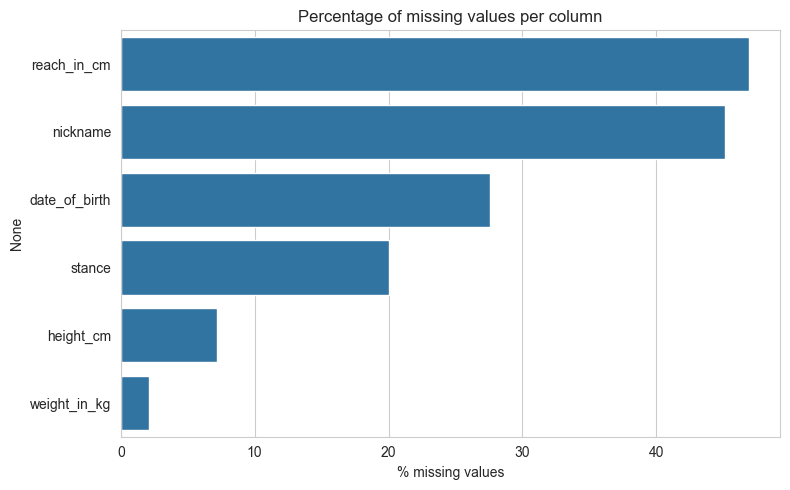

In [6]:
plt.figure(figsize=(8,5))
sns.barplot(x=pct[pct > 0].values, y=pct[pct > 0].index)
plt.xlabel('% missing values')
plt.title('Percentage of missing values per column')
plt.tight_layout()
plt.show()


## 3. Selecting the relevant features for *fighting style*

To separate styles, what matters isn't physical attributes (height/weight) or record
(wins/losses), but **how the fighter fights**: how much they strike, how much they absorb,
how much they take down, how much they attempt submissions.

Candidate features for clustering:
- `significant_strikes_landed_per_minute`
- `significant_striking_accuracy`
- `significant_strikes_absorbed_per_minute`
- `significant_strike_defence`
- `average_takedowns_landed_per_15_minutes`
- `takedown_accuracy`
- `takedown_defense`
- `average_submissions_attempted_per_15_minutes`

`height_cm`, `weight_in_kg`, `reach_in_cm`, `stance`, `wins/losses/draws` are left out of
the clustering itself, but they're great for *profiling* the clusters afterward (e.g. "cluster 2
tends to be taller with longer reach — matches a long-range striker profile").


In [7]:
style_features = [
    'significant_strikes_landed_per_minute',
    'significant_striking_accuracy',
    'significant_strikes_absorbed_per_minute',
    'significant_strike_defence',
    'average_takedowns_landed_per_15_minutes',
    'takedown_accuracy',
    'takedown_defense',
    'average_submissions_attempted_per_15_minutes',
]

df[style_features].isna().sum()


significant_strikes_landed_per_minute           0
significant_striking_accuracy                   0
significant_strikes_absorbed_per_minute         0
significant_strike_defence                      0
average_takedowns_landed_per_15_minutes         0
takedown_accuracy                               0
takedown_defense                                0
average_submissions_attempted_per_15_minutes    0
dtype: int64

Good news: these 8 columns have no missing values in the original dataset — they're the
only ones with a full `Non-Null Count` of 4111. That simplifies preprocessing for the
clustering step quite a bit.

## 4. Distributions of the style features

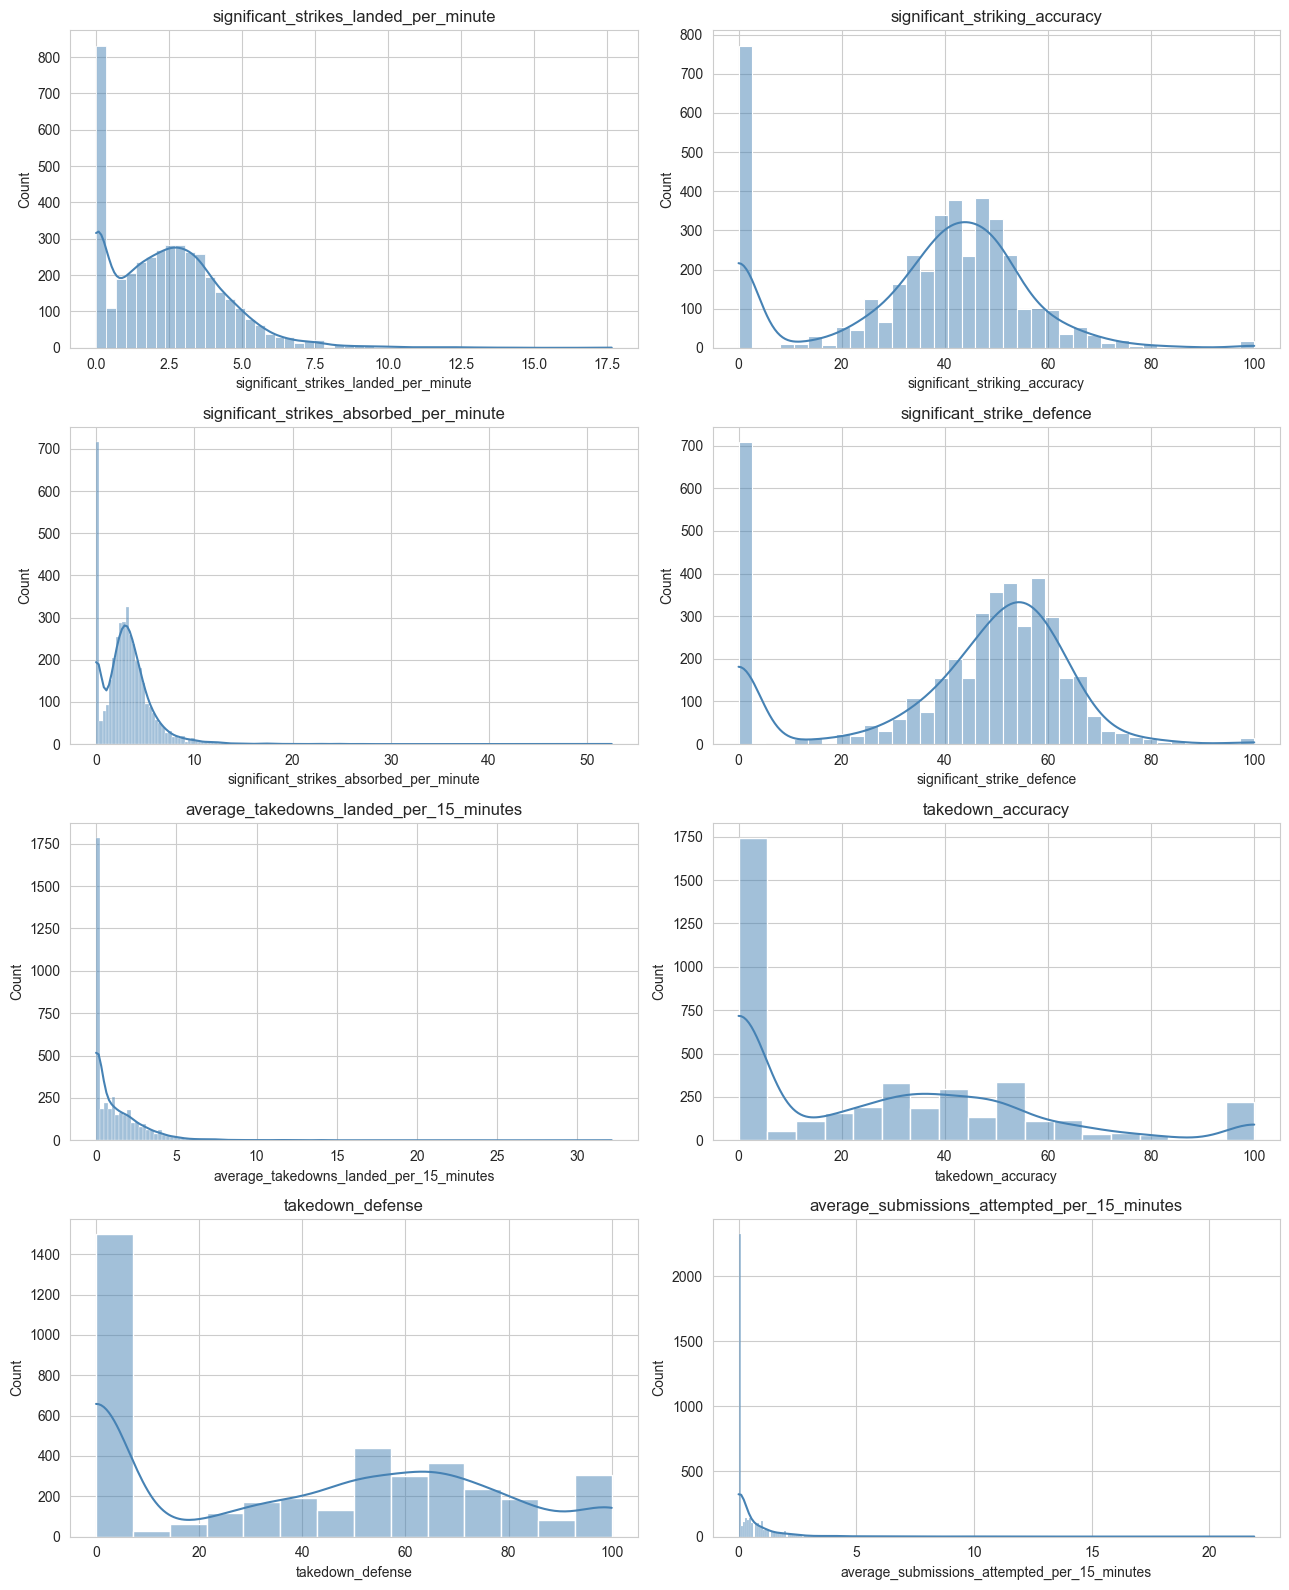

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(13, 16))
axes = axes.flatten()
for ax, col in zip(axes, style_features):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()


**What to look for here:**
- If a distribution is heavily skewed (long tail), a log transform before scaling may help —
  common in `average_submissions_attempted_per_15_minutes`, which tends to have many fighters
  near zero and a few with high values (grapplers).
- Bimodal peaks are already a visual hint of subgroups (e.g. strikers vs. grapplers in the
  takedown distribution).


## 5. Correlation between style features

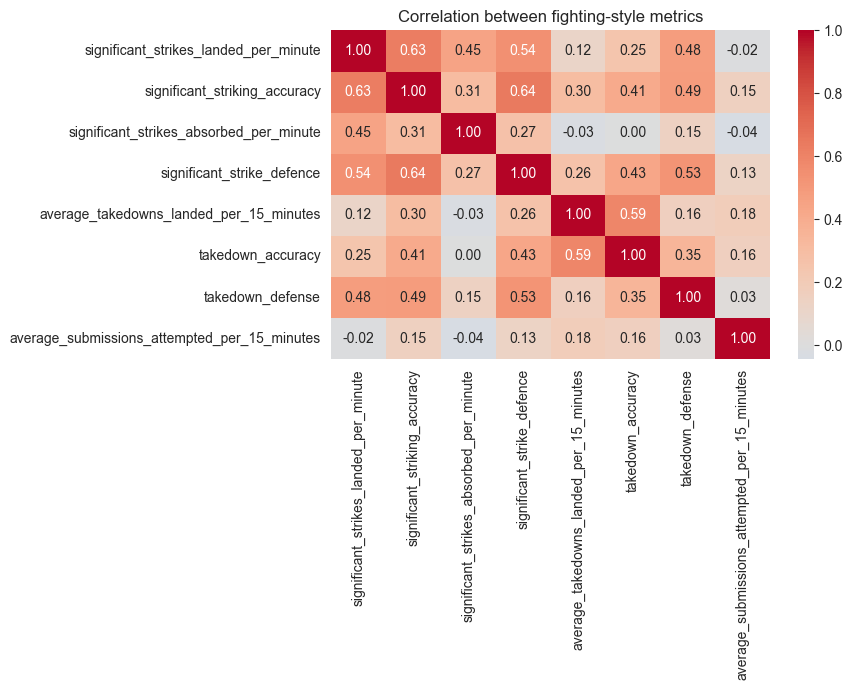

In [9]:
corr = df[style_features].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation between fighting-style metrics')
plt.tight_layout()
plt.show()


**Why this matters for clustering:** highly correlated features (e.g. `takedown_accuracy`
and `average_takedowns_landed_per_15_minutes`) carry redundant information and can end up
"weighing more" in K-Means' euclidean distance than intended. If correlation is high
(> 0.8~0.9), it's worth considering removing one of them or applying PCA before clustering.


## 6. Outliers in the style metrics

Outliers weigh heavily in distance-based algorithms (K-Means, hierarchical), since they can
pull entire centroids. Worth identifying before deciding on a treatment strategy.


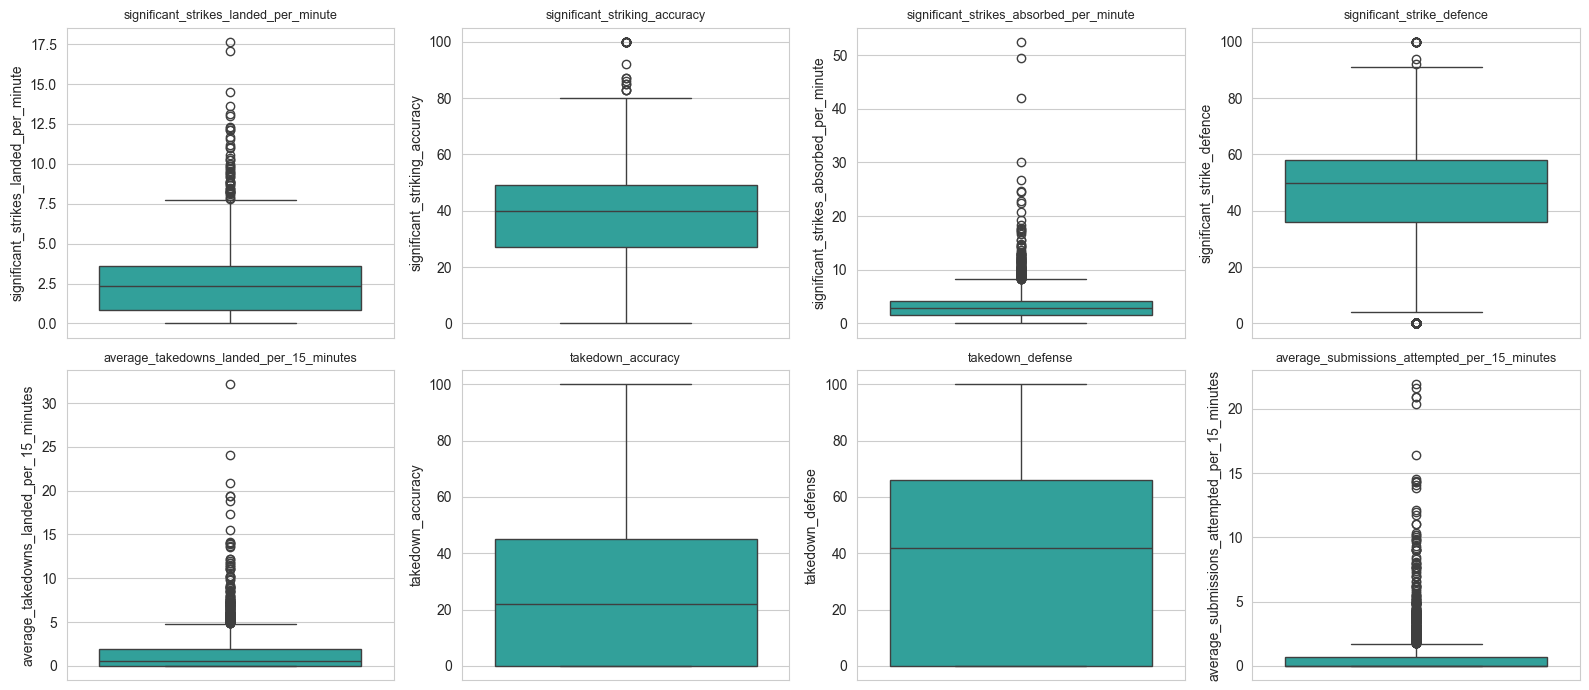

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for ax, col in zip(axes, style_features):
    sns.boxplot(y=df[col], ax=ax, color='lightseagreen')
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()


## 7. Exploring structure with PCA (before choosing the algorithm)

Dimensionality reduction helps visualize (in 2D) whether there's already natural separation
between groups, which hints at how many clusters might make sense later.


Explained variance: [0.40645365 0.1839788 ] -> sum: 0.5904324450978415


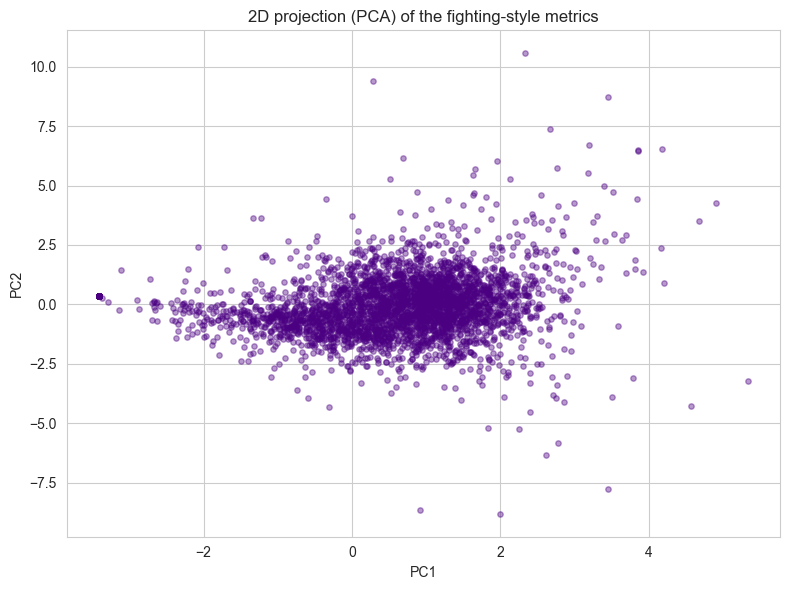

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[style_features].dropna()
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print('Explained variance:', pca.explained_variance_ratio_, '-> sum:', pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.4, s=15, color='indigo')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D projection (PCA) of the fighting-style metrics')
plt.tight_layout()
plt.show()


**Reading the plot:** if distinct "clouds" or densities show up, that's a sign real
separation exists in the data — a good omen for K-Means/GMM. If it's a single uniform cloud,
clusters may end up more artificial (arbitrary boundaries rather than natural groups), and
it's worth considering DBSCAN or revisiting the feature set.


## 8. Relating physical attributes to style (complementary analysis, outside the clustering)

Doesn't go into the model, but helps interpret the clusters later: do taller fighters/fighters
with more reach tend to have different striking metrics than shorter ones?


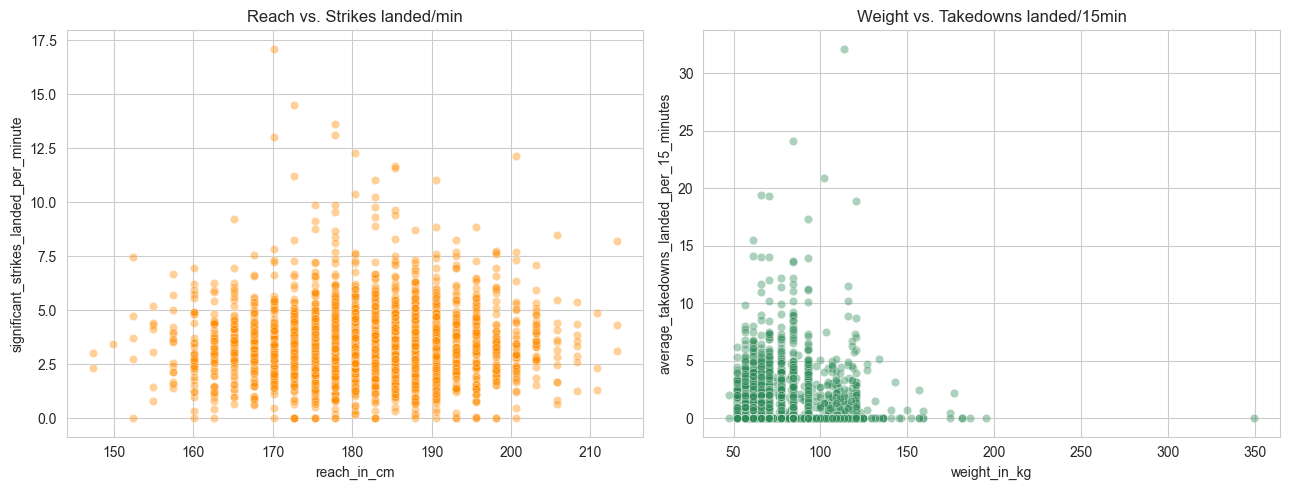

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.scatterplot(data=df, x='reach_in_cm', y='significant_strikes_landed_per_minute',
                alpha=0.4, ax=axes[0], color='darkorange')
axes[0].set_title('Reach vs. Strikes landed/min')

sns.scatterplot(data=df, x='weight_in_kg', y='average_takedowns_landed_per_15_minutes',
                alpha=0.4, ax=axes[1], color='seagreen')
axes[1].set_title('Weight vs. Takedowns landed/15min')
plt.tight_layout()
plt.show()


## 9. EDA summary — decisions for the modeling step

1. **Clustering features:** the 8 striking/takedown/submission metrics — no missing values, ready to use directly.
2. **Required preprocessing:** `StandardScaler` (very different scales — accuracy in % vs. strikes/min), and evaluate a log-transform on `average_submissions_attempted_per_15_minutes` if the distribution turns out very skewed.
3. **Correlation:** check the heatmap before deciding whether to apply PCA as an actual dimensionality reduction step (not just for visualization) — reduces redundancy between `takedown_accuracy` and `average_takedowns_landed_per_15_minutes`.
4. **Outliers:** decide whether to winsorize or keep them (extreme fighters may actually be pure examples of a style).
5. **Features outside the clustering** (`height_cm`, `weight_in_kg`, `reach_in_cm`, `stance`, `wins/losses/draws`) are reserved for **profiling** the clusters once formed, not for defining them.
6. **Next step:** Elbow method + Silhouette score to choose k, and compare K-Means vs. Gaussian Mixture (which handles elliptical-shaped clusters better, common when metrics are correlated with each other).
